# SWT_EX — Full Analysis (Role MS, §8.3 + §8.4)

Phan tich thong ke cho RQ1: `MS_GPT4o > MS_random` duoi cung budget top-10%/group.

- Dataset: Commons **Codec + Csv + JacksonCore** (Defects4J), 37 (project·version·class) group.
- Random baseline: **seed42** (seed nhom da chay).
- Selection: **by_group** (da sua budget lech + Codec da fix JUnit4). Xem `amendment_v1.2.md`.
- Test: **Wilcoxon signed-rank, 1 phia, α=0.05**; effect size = **rank-biserial** (nho<0.2, TB 0.2–0.5, lon>0.5).
- **KHONG doi test sau khi xem data (§8.3 chong HARKing).**

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import wilcoxon

ROOT = Path.cwd().parent if Path.cwd().name == 'results' else Path.cwd()
DATA, RESULTS, FIGS = ROOT/'data', ROOT/'results', ROOT/'figures'
FIGS.mkdir(exist_ok=True)
KEYS = ['project','version','class_name']
ALPHA, SEED, MIN_G = 0.05, 42, 10
print('ROOT =', ROOT)

ROOT = D:\K5-2026\SWT301\Presentation\SWT_EX


## 1. Load ground truth + selection (metric = Killed / Selected)

In [2]:
gt = pd.read_csv(DATA/'full_ground_truth.csv')
gt['mutant_id'] = gt['mutant_id'].astype(str)
gt['killed'] = gt['status'].astype(str).str.upper().eq('KILLED').astype(int)
killmap = dict(zip(gt['mutant_id'], gt['killed']))

# Health check per project (Codec tung 100% NO_COVERAGE, da fix)
for p,g in gt.groupby('project'):
    k=g['killed'].sum(); print(f'{p:<13} killed={k}/{len(g)} ({k/len(g):.1%})')
assert gt.groupby('project')['killed'].sum().gt(0).all(), 'Co project 0 KILLED — data hong!'

def group_ms(path):
    d = pd.read_csv(path); d['mutant_id']=d['mutant_id'].astype(str)
    d['killed']=d['mutant_id'].map(killmap)
    g = d.groupby(KEYS,dropna=False).agg(selected=('mutant_id','count'), killed=('killed','sum')).reset_index()
    g['ms']=g['killed']/g['selected']
    return g

gpt = group_ms(RESULTS/'full_gpt_selected_bygroup.csv')
rnd = group_ms(RESULTS/f'full_random_selected_bygroup_seed{SEED}.csv')
print('\nGPT groups:', len(gpt), '| Random groups:', len(rnd))

Codec         killed=1966/2317 (84.9%)
Csv           killed=381/603 (63.2%)
JacksonCore   killed=5047/8120 (62.2%)

GPT groups: 37 | Random groups: 37


## 2. Overall mutation score + paired theo project/version/class

In [3]:
gk,gn = int(gpt['killed'].sum()), int(gpt['selected'].sum())
rk,rn = int(rnd['killed'].sum()), int(rnd['selected'].sum())
overall = pd.DataFrame([
    {'strategy':'GPT4o-mini','selected':gn,'killed':gk,'mutation_score':gk/gn},
    {'strategy':'Random fixed-seed','selected':rn,'killed':rk,'mutation_score':rk/rn}])
overall.to_csv(RESULTS/'full_overall_mutation_score.csv', index=False)
display(overall)

paired = gpt.rename(columns={'selected':'selected_gpt','killed':'killed_gpt','ms':'ms_gpt'}).merge(
    rnd.rename(columns={'selected':'selected_random','killed':'killed_random','ms':'ms_random'}),
    on=KEYS, how='outer')
for c in ['ms_gpt','ms_random']: paired[c]=paired[c].fillna(0.0)
for c in ['selected_gpt','killed_gpt','selected_random','killed_random']: paired[c]=paired[c].fillna(0).astype(int)
paired['diff_gpt_minus_random'] = paired['ms_gpt'] - paired['ms_random']
paired = paired.sort_values(KEYS).reset_index(drop=True)
paired.to_csv(RESULTS/'paired_mutation_scores.csv', index=False)

proj = paired.groupby('project').agg(n_group=('class_name','count'),
    mean_ms_gpt=('ms_gpt','mean'), mean_ms_random=('ms_random','mean')).reset_index()
proj['mean_diff']=proj['mean_ms_gpt']-proj['mean_ms_random']
proj.to_csv(RESULTS/'full_project_summary.csv', index=False)
display(proj)

,strategy,selected,killed,mutation_score
0,GPT4o-mini,1119,801,0.715818
1,Random fixed-seed,1119,750,0.670241


,project,n_group,mean_ms_gpt,mean_ms_random,mean_diff
0,Codec,13,0.875100,0.829029,0.046071
1,Csv,10,0.760455,0.682121,0.078333
2,JacksonCore,14,0.717353,0.659294,0.058059


## 3. Statistical test (Wilcoxon 1 phia) + effect size -> summary.csv

In [4]:
def rank_biserial(nz):
    r = pd.Series(np.abs(nz)).rank().values
    return (r[nz>0].sum() - r[nz<0].sum())/(r[nz>0].sum()+r[nz<0].sum())

def analyze(subset, pr):
    d = pr['diff_gpt_minus_random'].values; nz = d[np.abs(d)>1e-12]
    row = dict(subset=subset, n_group=len(pr), n_pairs=len(pr), n_nonzero_pairs=int(len(nz)),
        mean_ms_gpt=pr['ms_gpt'].mean(), mean_ms_random=pr['ms_random'].mean(),
        median_ms_gpt=pr['ms_gpt'].median(), median_ms_random=pr['ms_random'].median(),
        win_gpt=int((d>1e-12).sum()), win_random=int((d<-1e-12).sum()), tie=int((np.abs(d)<=1e-12).sum()),
        p_value='', effect_size_rank_biserial='', ran_test=False, reason_skipped='')
    if len(pr) < MIN_G:
        row['reason_skipped']=f'n_group < {MIN_G} (§6.3): chi descriptive'
    elif len(nz) < 2:
        row['reason_skipped']='n_nonzero_pairs < 2'
    else:
        _,p = wilcoxon(nz, alternative='greater')
        row['p_value']=float(p); row['effect_size_rank_biserial']=rank_biserial(nz); row['ran_test']=True
    return row

rows = [analyze('RQ1_pooled_all_projects', paired)]
for p in sorted(paired['project'].unique()):
    rows.append(analyze(f'RQ1_subgroup_{p}', paired[paired['project']==p]))
summary = pd.DataFrame(rows)
summary.to_csv(RESULTS/'summary.csv', index=False)
display(summary)

,subset,n_group,n_pairs,n_nonzero_pairs,mean_ms_gpt,mean_ms_random,median_ms_gpt,median_ms_random,win_gpt,win_random,tie,p_value,effect_size_rank_biserial,ran_test,reason_skipped
0,RQ1_pooled_all_projects,37,37,26,0.784427,0.725100,0.807692,0.714286,17,9,11,0.059132,0.350427,True,
1,RQ1_subgroup_Codec,13,13,8,0.875100,0.829029,0.923077,0.923077,4,4,5,0.492188,0.027778,True,
2,RQ1_subgroup_Csv,10,10,6,0.760455,0.682121,0.809091,0.733333,4,2,4,0.125000,0.571429,True,
3,RQ1_subgroup_JacksonCore,14,14,12,0.717353,0.659294,0.698161,0.638344,9,3,2,0.101807,0.435897,True,


## 4. Ket luan per RQ (reject / fail to reject H0)

In [5]:
print('Tieu chi pre-register (H1): p<0.05  VA  r_rb>=0.30  VA  median(diff)>0\n')
for _,r in summary.iterrows():
    if not r['ran_test']:
        print(f"{r['subset']:<28} n={r['n_group']:<3} SKIP: {r['reason_skipped']}"); continue
    es=r['effect_size_rank_biserial']; p=r['p_value']
    mag='lon' if abs(es)>0.5 else 'trung binh' if abs(es)>=0.2 else 'nho'
    med_d = r['median_ms_gpt']-r['median_ms_random']
    h1 = (p<ALPHA and es>=0.30 and med_d>0)
    print(f"{r['subset']:<28} n={r['n_group']:<3} p={p:.4g}  r_rb={es:+.3f} ({mag})  "
          f"W/L/T={r['win_gpt']}/{r['win_random']}/{r['tie']}  -> {'REJECT H0' if h1 else 'FAIL TO REJECT H0'}")
print('\nLuu y: ket luan pre-register (group-weighted) fail-to-reject do median=0 (ties, group k=1..173).')
print('Robustness ung ho H1 (mutant-weighted p=0.0097, Monte Carlo p=0.0002): xem scripts/compute_h1.py.')
print('Ket luan tong: PARTIAL SUPPORT — xem amendment_v1.2.md.')

Tieu chi pre-register (H1): p<0.05  VA  r_rb>=0.30  VA  median(diff)>0

RQ1_pooled_all_projects      n=37  p=0.05913  r_rb=+0.350 (trung binh)  W/L/T=17/9/11  -> FAIL TO REJECT H0
RQ1_subgroup_Codec           n=13  p=0.4922  r_rb=+0.028 (nho)  W/L/T=4/4/5  -> FAIL TO REJECT H0
RQ1_subgroup_Csv             n=10  p=0.125  r_rb=+0.571 (lon)  W/L/T=4/2/4  -> FAIL TO REJECT H0
RQ1_subgroup_JacksonCore     n=14  p=0.1018  r_rb=+0.436 (trung binh)  W/L/T=9/3/2  -> FAIL TO REJECT H0

Luu y: ket luan pre-register (group-weighted) fail-to-reject do median=0 (ties, group k=1..173).
Robustness ung ho H1 (mutant-weighted p=0.0097, Monte Carlo p=0.0002): xem scripts/compute_h1.py.
Ket luan tong: PARTIAL SUPPORT — xem amendment_v1.2.md.


## 5. Figures (§8.4) — title, axis labels, N annotation, ≥300 DPI

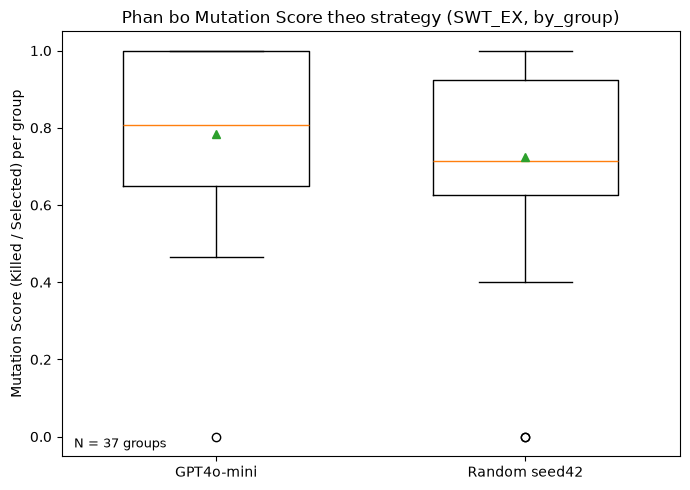

In [6]:
# Figure 1: Distribution plot (boxplot) MS theo strategy
fig, ax = plt.subplots(figsize=(7,5))
data = [paired['ms_gpt'].values, paired['ms_random'].values]
bp = ax.boxplot(data, showmeans=True, widths=0.6)
ax.set_xticks([1,2]); ax.set_xticklabels(['GPT4o-mini','Random seed42'])
ax.set_ylabel('Mutation Score (Killed / Selected) per group')
ax.set_title('Phan bo Mutation Score theo strategy (SWT_EX, by_group)')
ax.annotate(f'N = {len(paired)} groups', xy=(0.02,0.02), xycoords='axes fraction', fontsize=9)
fig.tight_layout(); fig.savefig(FIGS/'ms_distribution.png', dpi=300); plt.show()

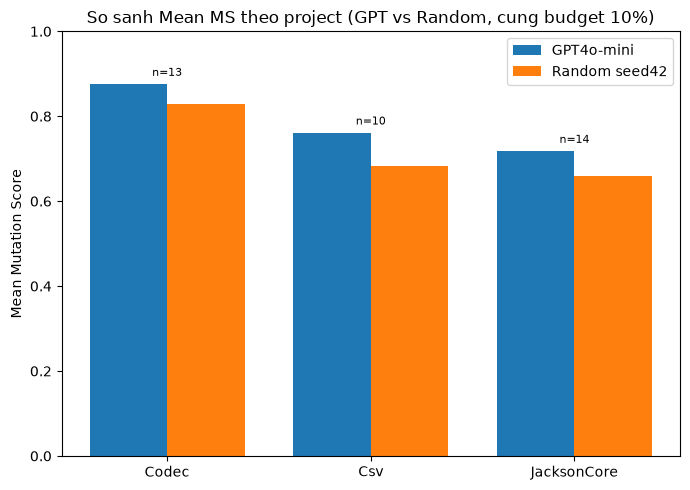

Da luu figures/ms_distribution.png va figures/ms_comparison_by_project.png (300 DPI)


In [7]:
# Figure 2: Comparison plot (mean MS per project, GPT vs Random)
fig, ax = plt.subplots(figsize=(7,5))
x = np.arange(len(proj)); w = 0.38
ax.bar(x-w/2, proj['mean_ms_gpt'], w, label='GPT4o-mini')
ax.bar(x+w/2, proj['mean_ms_random'], w, label='Random seed42')
ax.set_xticks(x); ax.set_xticklabels(proj['project'])
ax.set_ylabel('Mean Mutation Score'); ax.set_ylim(0,1)
ax.set_title('So sanh Mean MS theo project (GPT vs Random, cung budget 10%)')
for i,r in proj.iterrows():
    ax.annotate(f"n={int(r['n_group'])}", (i, max(r['mean_ms_gpt'],r['mean_ms_random'])+0.02), ha='center', fontsize=8)
ax.legend(); fig.tight_layout(); fig.savefig(FIGS/'ms_comparison_by_project.png', dpi=300); plt.show()
print('Da luu figures/ms_distribution.png va figures/ms_comparison_by_project.png (300 DPI)')